## Final Project
**Description of Question and Research Topic:**

Facial expressions convey non-verbal signals commonly grouped into seven basic emotions: angry, disgust, fear, happy, sad, surprise, and neutral. This project studies whether a single, compact convolutional neural network (CNN) trained from scratch can accurately classify emotions across two different datasets. We evaluate accuracy, macro-F1, and per-class precision/recall, and test robustness to blur, occlusion, and low light to understand real-world performance. Gradient-based saliency visualizations are used to inspect which facial regions influence predictions and to analyze common failure modes (e.g., fear vs. surprise). We further perform cross-dataset experiments (train on Dataset-A, test on Dataset-B and vice versa) to quantify domain shift and validate the generality of the shared CNN.

**Authors:** Kareem Atout (@kareematout), Muhammad Kamran Khan (@kamivibra111)  
**Course:** CS 171 — Final Project (Facial Emotion Recognition)  
**Notebook:** Initial Data Preparation (FER2013)


We treat FER2013 as Dataset-A in our project assigned to me (Muhammad Kamran Khan) and RAF-DB as Dataset-B (assigned to Kareem Atout). This notebook focuses on starting the preprocessing for Dataset-A.


# Data Preparation (Initial Work)
This notebook begins the data preparation process for our Facial Emotion Recognition (FER) project.  
Goal: verify dataset access, import libraries, and load a small sample of FER2013 to confirm the preprocessing pipeline.


In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from pathlib import Path
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
import json

# Make plots show inline (harmless even if Jupyter does it automatically)
%matplotlib inline

# --- Paths & config ---

# This assumes the notebook is in `notebooks/` inside the repo
PROJECT_ROOT = Path("..").resolve()

RAW_FER_DIR = PROJECT_ROOT / "src" / "data" / "fer2013"
OUTPUT_ROOT = PROJECT_ROOT / "data" / "fer2013"

IMG_SIZE = (64, 64)      # final image size for the CNN
RANDOM_SEED = 171        # for reproducible splits

print("Project root:", PROJECT_ROOT)
print("Raw FER dir:", RAW_FER_DIR)
print("Output root:", OUTPUT_ROOT)
print("Image size:", IMG_SIZE)


Project root: /Users/kami4/Documents/SJSU/CS_171/FinalPoject/facial-emotion-recognition-cnn
Raw FER dir: /Users/kami4/Documents/SJSU/CS_171/FinalPoject/facial-emotion-recognition-cnn/src/data/fer2013
Output root: /Users/kami4/Documents/SJSU/CS_171/FinalPoject/facial-emotion-recognition-cnn/data/fer2013
Image size: (64, 64)


In [12]:
!pip install tqdm

## Preprocessing Plan
- Load FER2013 images from `train/` and `test/` folders
- Resize all images to 64×64
- Convert grayscale images to 3-channel RGB
- Create train/val/test splits (train → train + val)
- Save processed images under `data/fer2013/...`
- Plot class distributions and show sample images


## Verify the Images raw Directory FER2013 exists

In [6]:
# Verify the FER2013 raw directory exists
print("FER2013 raw directory exists:", RAW_FER_DIR.exists())

train_dir = RAW_FER_DIR / "train"
test_dir = RAW_FER_DIR / "test"

print("\nTrain dir:", train_dir, "| exists:", train_dir.exists())
print("Test dir:", test_dir, "| exists:", test_dir.exists())

print("\nTrain emotion folders:")
if train_dir.exists():
    for item in sorted(train_dir.iterdir()):
        if item.is_dir():
            print(" -", item.name)

print("\nTest emotion folders:")
if test_dir.exists():
    for item in sorted(test_dir.iterdir()):
        if item.is_dir():
            print(" -", item.name)


FER2013 raw directory exists: True

Train dir: /Users/kami4/Documents/SJSU/CS_171/FinalPoject/facial-emotion-recognition-cnn/src/data/fer2013/train | exists: True
Test dir: /Users/kami4/Documents/SJSU/CS_171/FinalPoject/facial-emotion-recognition-cnn/src/data/fer2013/test | exists: True

Train emotion folders:
 - angry
 - disgust
 - fear
 - happy
 - neutral
 - sad
 - surprise

Test emotion folders:
 - angry
 - disgust
 - fear
 - happy
 - neutral
 - sad
 - surprise


In [8]:
def build_image_df(split_dir: Path, split_name: str) -> pd.DataFrame:
    """
    Scan a split directory (e.g., train/ or test/) and build a dataframe
    with columns: filepath, label, split.
    """
    rows = []

    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        label = class_dir.name  # e.g. "angry", "happy", etc.
        for img_path in class_dir.glob("*.*"):
            rows.append(
                {
                    "filepath": img_path,
                    "label": label,
                    "split": split_name,
                }
            )

    return pd.DataFrame(rows)

# Build dataframes
train_df = build_image_df(train_dir, "train")
test_df = build_image_df(test_dir, "test")

print("Number of train images:", len(train_df))
print("Number of test images:", len(test_df))

print("\nTrain label counts:")
print(train_df["label"].value_counts())

print("\nTest label counts:")
print(test_df["label"].value_counts())

train_df.head()


Number of train images: 28709
Number of test images: 7178

Train label counts:
label
happy       7215
neutral     4965
sad         4830
fear        4097
angry       3995
surprise    3171
disgust      436
Name: count, dtype: int64

Test label counts:
label
happy       1774
sad         1247
neutral     1233
fear        1024
angry        958
surprise     831
disgust      111
Name: count, dtype: int64


,filepath,label,split
0,/Users/kami4/Documents/SJSU/CS_171/FinalPoject...,angry,train
1,/Users/kami4/Documents/SJSU/CS_171/FinalPoject...,angry,train
2,/Users/kami4/Documents/SJSU/CS_171/FinalPoject...,angry,train
3,/Users/kami4/Documents/SJSU/CS_171/FinalPoject...,angry,train
4,/Users/kami4/Documents/SJSU/CS_171/FinalPoject...,angry,train


# Create a validation split
We will split the training set into:

* train

* val

* test (already provided by FER2013)

In [9]:
# Create train/validation split from train_df
train_df_split, val_df = train_test_split(
    train_df,
    test_size=0.1,      # 10% validation
    random_state=RANDOM_SEED,
    stratify=train_df["label"]  # keeps balanced emotion distribution
)

# Rename split labels
train_df_split = train_df_split.copy()
train_df_split["split"] = "train"

val_df = val_df.copy()
val_df["split"] = "val"

print("New train size:", len(train_df_split))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

print("\nValidation label counts:")
print(val_df["label"].value_counts())


New train size: 25838
Val size: 2871
Test size: 7178

Validation label counts:
label
happy       722
neutral     496
sad         483
fear        410
angry       399
surprise    317
disgust      44
Name: count, dtype: int64


## Create Output Directory Structure

Before processing the images, we create a standardized folder structure for the final dataset. Each split (train, val, test) will contain seven emotion-specific subfolders.


In [10]:
# Create output folders: train, val, test, with emotion subfolders

splits = ["train", "val", "test"]
labels = sorted(train_df["label"].unique())  # all 7 emotion classes

for split in splits:
    for label in labels:
        out_dir = OUTPUT_ROOT / split / label
        out_dir.mkdir(parents=True, exist_ok=True)

print("Created directory structure under:", OUTPUT_ROOT)


Created directory structure under: /Users/kami4/Documents/SJSU/CS_171/FinalPoject/facial-emotion-recognition-cnn/data/fer2013


## Process and Save FER2013 Images (Resize + RGB Conversion)

In this section, we convert all FER2013 images to a consistent format used by our shared CNN.  
Each image is loaded, converted from grayscale to 3-channel RGB, resized to 64×64, and saved into the appropriate output folder.  
This matches the preprocessing applied to RAF-DB, ensuring the model receives consistent input across datasets.


In [13]:
from tqdm import tqdm  # if this fails, remove and use a simple range loop instead

def process_and_save_images(df: pd.DataFrame, split_name: str):
    """
    For each row in the dataframe, load the image, convert to RGB,
    resize to IMG_SIZE, and save it into data/fer2013/{split}/{label}/.
    """
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split_name}"):
        src_path = Path(row["filepath"])
        label = row["label"]

        # Destination path: data/fer2013/split/label/filename.png
        dst_path = OUTPUT_ROOT / split_name / label / src_path.name

        # Skip if already processed (useful if you re-run the cell)
        if dst_path.exists():
            continue

        # Load image
        img = Image.open(src_path)

        # Convert to RGB (handles grayscale or already-color images)
        img = img.convert("RGB")

        # Resize
        img = img.resize(IMG_SIZE)

        # Save
        img.save(dst_path)

# Run processing for each split
process_and_save_images(train_df_split, "train")
process_and_save_images(val_df, "val")
process_and_save_images(test_df, "test")

print("Finished processing and saving all FER2013 images.")


Processing test: 100%|████████████████████| 7178/7178 [00:01<00:00, 4546.77it/s]

Finished processing and saving all FER2013 images.


## Class Distribution After Preprocessing

Now that all images have been processed and saved into the final directory structure,  
we visualize the class distribution for the train, validation, and test splits.  
This confirms that the stratified split preserved label balance across all subsets.


In [16]:
# Count images in output folders

def count_images_in_split(split_name: str):
    split_counts = {}
    split_path = OUTPUT_ROOT / split_name

    for label in sorted(os.listdir(split_path)):
        label_dir = split_path / label
        if not label_dir.is_dir():
            continue
        # Count all files in this label directory (jpg, png, etc.)
        split_counts[label] = len(list(label_dir.glob("*.*")))
    return split_counts

train_counts = count_images_in_split("train")
val_counts = count_images_in_split("val")
test_counts = count_images_in_split("test")

print("Train counts:", train_counts)
print("Val counts:  ", val_counts)
print("Test counts: ", test_counts)



Train counts: {'angry': 3596, 'disgust': 392, 'fear': 3687, 'happy': 6493, 'neutral': 4469, 'sad': 4347, 'surprise': 2854}
Val counts:   {'angry': 399, 'disgust': 44, 'fear': 410, 'happy': 722, 'neutral': 496, 'sad': 483, 'surprise': 317}
Test counts:  {'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}


In [19]:
# Create a pretty table for label distribution summary

import pandas as pd

# combine train + test into a DataFrame
summary_df = pd.DataFrame({
    "Emotion": sorted(train_counts.keys()),
    "Train_Count": [train_counts[l] for l in sorted(train_counts.keys())],
    "Test_Count":  [test_counts[l]  for l in sorted(test_counts.keys())],
})

# add total / percentages
summary_df["Total_Count"] = summary_df["Train_Count"] + summary_df["Test_Count"]
summary_df["Train_Percent"] = (summary_df["Train_Count"] / summary_df["Total_Count"] * 100).round(2)
summary_df["Test_Percent"]  = (summary_df["Test_Count"]  / summary_df["Total_Count"] * 100).round(2)

# Add label numbers (1–7)
summary_df.insert(0, "Label", range(1, len(summary_df) + 1))

# Print in formatted style
print("Label Distribution Summary:")
print("="*82)
print(summary_df.to_string(index=False))
print("="*82)


Label Distribution Summary:
 Label  Emotion  Train_Count  Test_Count  Total_Count  Train_Percent  Test_Percent
     1    angry         3596         958         4554          78.96         21.04
     2  disgust          392         111          503          77.93         22.07
     3     fear         3687        1024         4711          78.26         21.74
     4    happy         6493        1774         8267          78.54         21.46
     5  neutral         4469        1233         5702          78.38         21.62
     6      sad         4347        1247         5594          77.71         22.29
     7 surprise         2854         831         3685          77.45         22.55


# Emotion Distribution Plot
This visualization places the FER2013 train and test label distributions. It helps compare class imbalance across splits and ensures both are aligned before training our CNN.

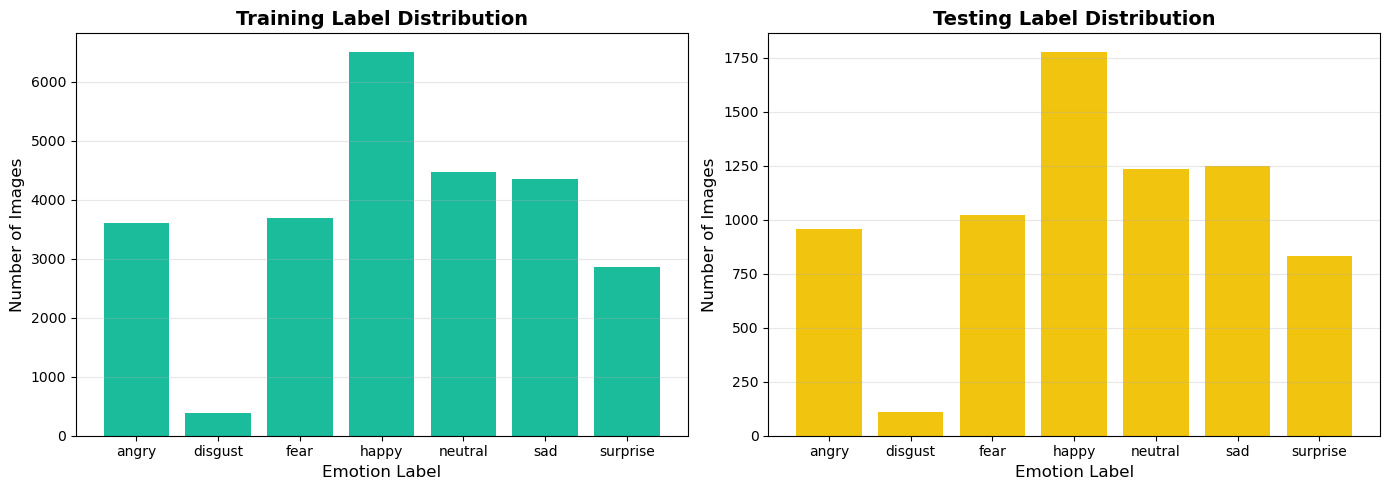

In [24]:
emotion_labels = summary_df["Emotion"].tolist()
train_values   = summary_df["Train_Count"].tolist()
test_values    = summary_df["Test_Count"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color palette
train_color = '#1ABC9C'   # teal
test_color  = '#F1C40F'   # gold

# --- Train plot ---
axes[0].bar(range(1, 8), train_values, color=train_color)
axes[0].set_title("Training Label Distribution", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Emotion Label", fontsize=12)
axes[0].set_ylabel("Number of Images", fontsize=12)
axes[0].set_xticks(range(1, 8))
axes[0].set_xticklabels(emotion_labels, rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# --- Test plot ---
axes[1].bar(range(1, 8), test_values, color=test_color)
axes[1].set_title("Testing Label Distribution", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Emotion Label", fontsize=12)
axes[1].set_ylabel("Number of Images", fontsize=12)
axes[1].set_xticks(range(1, 8))
axes[1].set_xticklabels(emotion_labels, rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



# Sample Images from FER2013 (Processed)
This grid shows one example image from each emotion class after preprocessing.
It helps verify that the processed images look correct and that they were saved into the right folders.

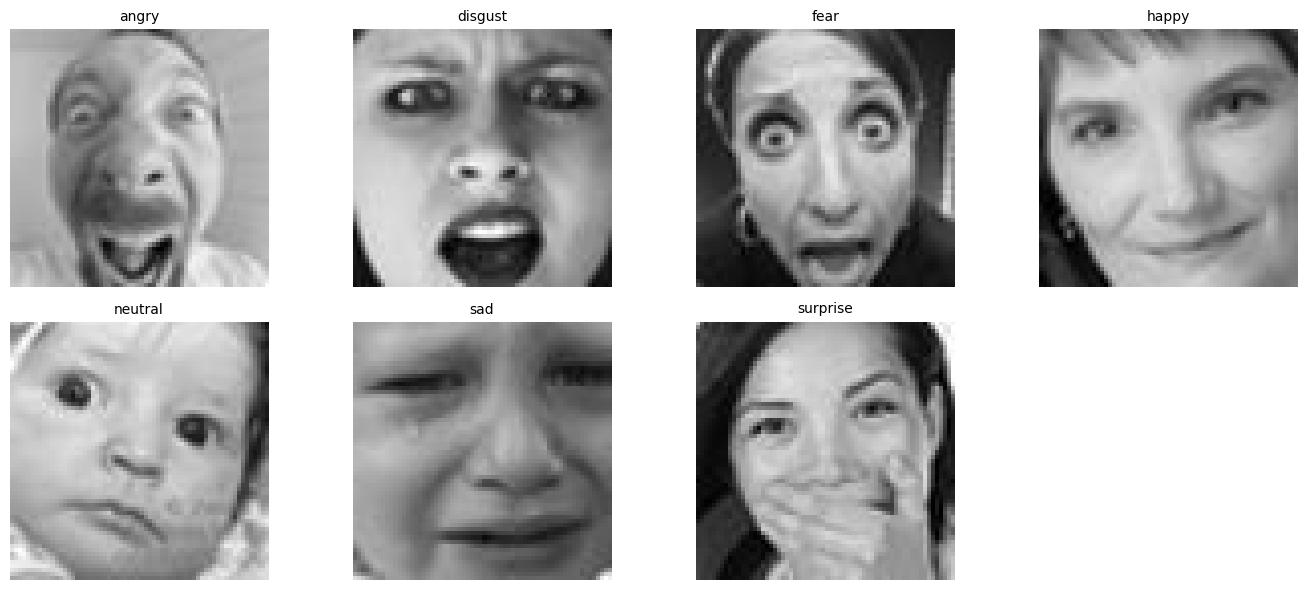

In [25]:
from PIL import Image
import matplotlib.pyplot as plt

# Pick one sample image per emotion (from the TRAIN split)
sample_images = []

for emotion in emotion_labels:
    folder = OUTPUT_ROOT / "train" / emotion
    img_path = list(folder.glob("*"))[0]   # take first image found
    sample_images.append((emotion, img_path))

# Plot
plt.figure(figsize=(14, 6))

for i, (emotion, img_path) in enumerate(sample_images, 1):
    img = Image.open(img_path)
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(emotion, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()


## Save FER2013 Label Mappings

Here I create a small metadata file that maps each emotion name to a numeric label and back again. This will be useful later when we build the CNN, because the model will train on numeric labels but I still want to see readable emotion names.


In [27]:
# Directory to store metadata (JSON / CSV summaries)
metadata_dir = OUTPUT_ROOT / "metadata_fer2013"
metadata_dir.mkdir(parents=True, exist_ok=True)

# Standard emotion order for FER2013 (matches my folder names)
FER2013_EMOTION_LABELS = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]

targets_map = {
    "emotion_to_label": {name: idx for idx, name in enumerate(FER2013_EMOTION_LABELS)},
    "label_to_emotion": {idx: name for idx, name in enumerate(FER2013_EMOTION_LABELS)},
    # FER2013 already uses this standard ordering, so the mapping is identity
    "fer2013_to_standard": {idx: idx for idx in range(len(FER2013_EMOTION_LABELS))},
    "fer2013_labels": FER2013_EMOTION_LABELS,
}

# Save to JSON
with open(metadata_dir / "targets_map_fer2013.json", "w") as f:
    json.dump(targets_map, f, indent=2)

print(json.dumps(targets_map, indent=2))


{
  "emotion_to_label": {
    "angry": 0,
    "disgust": 1,
    "fear": 2,
    "happy": 3,
    "sad": 4,
    "surprise": 5,
    "neutral": 6
  },
  "label_to_emotion": {
    "0": "angry",
    "1": "disgust",
    "2": "fear",
    "3": "happy",
    "4": "sad",
    "5": "surprise",
    "6": "neutral"
  },
  "fer2013_to_standard": {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6
  },
  "fer2013_labels": [
    "angry",
    "disgust",
    "fear",
    "happy",
    "sad",
    "surprise",
    "neutral"
  ]
}


## Split Counts Summary (Train / Val / Test)

Next I summarize how many images I have for each emotion in the train, validation,
and test sets. This lets me double-check that my 80/20 split worked correctly and
that the class balance is reasonable. I also save this summary to a CSV file so
we can easily inspect it later.


In [33]:
# Use the same emotion order as above
order = FER2013_EMOTION_LABELS

split_counts = pd.DataFrame({
    "Label": range(1, len(order) + 1),
    "Emotion": [name.capitalize() for name in order],
    "Train_Count": [train_counts[name] for name in order],
    "Val_Count":   [val_counts[name]   for name in order],
    "Test_Count":  [test_counts[name]  for name in order],
})

# Totals and percentages
split_counts["Total_Count"]   = (
    split_counts["Train_Count"] + split_counts["Val_Count"] + split_counts["Test_Count"]
)
split_counts["Train_Percent"] = (
    split_counts["Train_Count"] / split_counts["Train_Count"].sum() * 100
).round(2)
split_counts["Val_Percent"] = (
    split_counts["Val_Count"] / split_counts["Val_Count"].sum() * 100
).round(2)
split_counts["Test_Percent"] = (
    split_counts["Test_Count"] / split_counts["Test_Count"].sum() * 100
).round(2)

# Re-order columns to look nice
split_counts = split_counts[
    [
        "Label",
        "Emotion",
        "Train_Count",
        "Train_Percent",
        "Val_Count",
        "Val_Percent",
        "Test_Count",
        "Test_Percent",
        "Total_Count",
    ]
]

# Save to CSV and print nicely
csv_path = metadata_dir / "split_counts_fer2013.csv"
split_counts.to_csv(csv_path, index=False)

print("Split counts summary:")
print("=" * 106)
print(split_counts.to_string(index=False))
print("=" * 106)
#print(f"\nSaved CSV to: {csv_path}")


Split counts summary:
 Label  Emotion  Train_Count  Train_Percent  Val_Count  Val_Percent  Test_Count  Test_Percent  Total_Count
     1    Angry         3596          13.92        399        13.90         958         13.35         4953
     2  Disgust          392           1.52         44         1.53         111          1.55          547
     3     Fear         3687          14.27        410        14.28        1024         14.27         5121
     4    Happy         6493          25.13        722        25.15        1774         24.71         8989
     5      Sad         4347          16.82        483        16.82        1247         17.37         6077
     6 Surprise         2854          11.05        317        11.04         831         11.58         4002
     7  Neutral         4469          17.30        496        17.28        1233         17.18         6198


## Dataset Statistics JSON

Finally, I save a small JSON file with high-level dataset statistics for FER2013.
It records how many images are in each split, how many emotion classes there are,
and what preprocessing configuration I used (image size and color mode).


In [35]:
dataset_stats = {
    "dataset": "FER2013",
    "total_images": int(split_counts["Total_Count"].sum()),
    "train_images": int(split_counts["Train_Count"].sum()),
    "val_images":   int(split_counts["Val_Count"].sum()),
    "test_images":  int(split_counts["Test_Count"].sum()),
    "num_classes":  len(FER2013_EMOTION_LABELS),
    "emotions":     [name.capitalize() for name in FER2013_EMOTION_LABELS],
    "target_size":  list(IMG_SIZE),           # (64, 64)
    "color_mode":   "grayscale",
    "train_val_split": "80/20",
    "preprocessing": {
        "resize":        list(IMG_SIZE),
        "normalization": "To be applied during training",
        "augmentation":  "To be applied during training",
    },
}

stats_path = metadata_dir / "dataset_stats_fer2013.json"
with open(stats_path, "w") as f:
    json.dump(dataset_stats, f, indent=2)

print(json.dumps(dataset_stats, indent=2))
# print(f"\nSaved dataset stats to: {stats_path}")


{
  "dataset": "FER2013",
  "total_images": 35887,
  "train_images": 25838,
  "val_images": 2871,
  "test_images": 7178,
  "num_classes": 7,
  "emotions": [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
  ],
  "target_size": [
    64,
    64
  ],
  "color_mode": "grayscale",
  "train_val_split": "80/20",
  "preprocessing": {
    "resize": [
      64,
      64
    ],
    "normalization": "To be applied during training",
    "augmentation": "To be applied during training"
  }
}
